# Robustness: MSSD threshold tested against assumptions

*Author: Tien (Tyler) Le 
Date: 2026-09-04*

---Every simulation in this folder so far generates EMA data from the **same stationaryAR(1) process the decision engine implicitly assumes**. `sensitivity_analysis.ipynb`sweeps response rate and threshold quantile; `mssd_validation.py` shows MSSD recoverslatent volatility. Both hold $\sigma$ and $\rho$ fixed for the whole study, so theengine has never been scored against data it was not designed for.Prof. 


*GOAL:* **break the assumption and see how the threshold behaves.**

 The assumption under test`backend/decision_engine/decision_engine.py` sets each participant's trigger threshold as an **expanding** within-person quantile:```pythondf["user_threshold"] = (    df.groupby("user_id")["observed_mssd"]    .transform(lambda s: s.expanding(min_periods=3).quantile(threshold_quantile).shift(1)))```Expanding means *it never forgets*. 

Every observation the participant has ever produced carries equal weight forever. 

`analysis-resources/data-dictionary.md` reinforces this by reserving Week 1 as a non-interventional run-in used **solely to calibrate this threshold**. Both are correct if a participant's volatility is a fixed personal trait. If it is not : if a stressor onset, an injury, a losing streak, or plain habituation moves it mid-study —the threshold is anchored to a regime that no longer exists.

### What this notebook runs

| Scenario | Latent volatility path | Represents |
|---|---|---|
| `stationary` | $\sigma_t = \sigma_0$ | control: exactly what the engine assumes |
| `shift_up` | $\sigma_0 \to 2\sigma_0$ at day 14 | stressor onset (expected MSSD $\times 4$) |
| `shift_down` | $\sigma_0 \to 0.5\,\sigma_0$ at day 14 | habituation / recovery |
| `drift` | $\log\sigma_t$ = AR(1), $\phi = 0.97$ | non-stationary volatility, no clean breakpoint |

Each is scored against the **real production functions** (`calculate_mssd`,`apply_decision_rules`), and against a rolling-window threshold carried purely as a**diagnostic contrast** — no backend change is proposed here; the threshold is a designparameter requiring PI sign-off.

In [3]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

HERE = os.getcwd()
REPO = HERE
while REPO != os.path.dirname(REPO) and not os.path.isdir(
        os.path.join(REPO, "backend", "decision_engine")):
    REPO = os.path.dirname(REPO)
if not os.path.isdir(os.path.join(REPO, "backend", "decision_engine")):
    raise RuntimeError("run this notebook from inside the REACT repo")

for p in (os.path.join(REPO, "backend"), os.path.join(REPO, "backend", "syntheticData")):
    if p not in sys.path:
        sys.path.insert(0, p)



In [5]:
from decision_engine.decision_engine import (
    calculate_mssd, apply_decision_rules, add_within_person_threshold)
from synthetic_generator import _clustered_missing_mask

BASE = os.path.join(REPO, "analytics", "sensitivity_analysis")
FIG_DIR = os.path.join(BASE, "figures", "robustness")
OUT_DIR = os.path.join(BASE, "outputs")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)
print("repo ::", REPO)
print("figures ::", FIG_DIR)
print("outputs ::", OUT_DIR)

repo :: /Users/tienle/Documents/Coding/REACT-SMASH/REACT
figures :: /Users/tienle/Documents/Coding/REACT-SMASH/REACT/analytics/sensitivity_analysis/figures/robustness
outputs :: /Users/tienle/Documents/Coding/REACT-SMASH/REACT/analytics/sensitivity_analysis/outputs


In [6]:
THRESHOLD_QUANTILE      = 0.80
COOLDOWN_MINUTES        = 60
MAX_PROMPTS_PER_DAY     = 4
MSSD_WINDOW             = 3
RANDOMIZATION_P         = 0.50

DAYS        = 35
SHIFT_DAY   = 14
EMA_PER_DAY = 5
RESP_RATE   = 0.80
MEAN_GAP    = 3

USERS   = 150
N_REPS  = 10
SEED    = 42
ROLLING_WINDOW = 35

LIKERT_LO, LIKERT_HI = 1, 7
N_PROMPTS = DAYS * EMA_PER_DAY
SHIFT_IDX = SHIFT_DAY * EMA_PER_DAY
STUDY_START = pd.Timestamp("2026-08-25") # arbitrary lol
SCENARIOS = ["stationary", "shift_up", "shift_down", "drift"]

## 1 · Generating data the engine was not designed for`generate_cohort` in `synthetic_generator.py` is fixed to one scalar $\sigma$ perparticipant and to the legacy 1–5 Likert scale, so it cannot express a volatility path.The generator below is the same AR(1) construction as `react_cohort.py`, changed inexactly two ways:1. it takes a **per-prompt $\sigma_t$ path** instead of a scalar, and2. it emits the **1–7 production scale** (`EMA` carries `MinValueValidator(1)` /   `MaxValueValidator(7)`).Clustered missingness is reused unchanged from `synthetic_generator._clustered_missing_mask`.Two details that matter:- **Timestamps.** The old notebook called `run_decision_engine.spread_ema_timestamps`,  a file that is gone from the repo and from git history. Its behaviour is recoverable  from `analytics/REACT-dashboard/data/decision_log.csv` and is reimplemented below.  This is not cosmetic: the raw generator emits prompts one *minute* apart, which would  make the 60-minute cooldown swallow every eligible decision.- **Common random numbers.** The standard normals are drawn once per participant and  reused across scenarios, so a participant's pre-shift series is byte-identical in  every scenario. Only the $\sigma$ path differs, which is what makes the comparison paired.> With a time-varying $\sigma$ the marginal SD tracks $\sigma_t$ only approximately —> after a jump the process needs $\sim 1/(1-\rho)$ steps to reach its new variance. That> transient is part of what is being measured, not an artefact.

In [ ]:
def spread_ema_timestamps(n_prompts, ema_per_day, start = STUDY_START):
    """Reconstruction of the deleted run_decision_engine.spread_ema_timestamps.

    Behaviour recovered from analytics/REACT-dashboard/data/decision_log.csv:
    prompt k of day d lands at 09:00 + 3h*k -> 09,12,15,18,21 for 5/day.
    Without this the generator's freq='min' grid makes the 60-minute cooldown
    swallow every eligible decision.
    """
    idx = np.arange(n_prompts)
    day = idx // ema_per_day
    k = idx % ema_per_day
    step_hours = 12.0 / (ema_per_day - 1) if ema_per_day > 1 else 0.0
    offs = pd.to_timedelta(day * 24.0 + 9.0 + k * step_hours, unit="h")
    return start + offs


def sigma_schedule(kind, sigma0, n=N_PROMPTS, shift_idx=SHIFT_IDX, rng=None,
                   shift_factor=2.0, phi=0.97, vol_of_vol=0.10,
                   lo=0.25, hi=2.0):
    """Per-prompt latent volatility path sigma_t for one participant."""
    if kind == "stationary":
        return np.full(n, sigma0)
    if kind == "shift_up":
        s = np.full(n, sigma0)
        s[shift_idx:] = sigma0 * shift_factor
        return np.clip(s, lo, hi)
    if kind == "shift_down":
        s = np.full(n, sigma0)
        s[shift_idx:] = sigma0 / shift_factor
        return np.clip(s, lo, hi)
    if kind == "drift":
        e = rng.standard_normal(n)
        log_s = np.empty(n)
        log_s[0] = np.log(sigma0)
        anchor = np.log(sigma0)
        for t in range(1, n):
            log_s[t] = anchor + phi * (log_s[t - 1] - anchor) + vol_of_vol * e[t]
        return np.clip(np.exp(log_s), lo, hi)
    raise ValueError(f"unknown schedule {kind}")


def generate_nonstationary_user(user_key, sigma_path, rho, mu, eps, miss_rng,
                                resp_rate=RESP_RATE, mean_gap_length=MEAN_GAP,
                                ema_per_day=EMA_PER_DAY):
    """AR(1) EMA series with a time-varying innovation scale.

    Mirrors synthetic_generator.generate_user / react_cohort.py but (a) takes a
    per-prompt sigma path instead of a scalar and (b) uses the 1-7 production
    Likert scale (EMA MinValueValidator(1)/MaxValueValidator(7)).

    `eps` is a pre-drawn standard-normal vector so that two scenarios sharing a
    sigma prefix produce byte-identical pre-shift series (common random numbers).
    """
    n = len(sigma_path)
    z = np.empty(n)
    scale = sigma_path * np.sqrt(1.0 - rho ** 2)
    z[0] = sigma_path[0] * eps[0]
    for t in range(1, n):
        z[t] = rho * z[t - 1] + scale[t] * eps[t]

    latent = mu + z
    ema = np.clip(np.round(latent), LIKERT_LO, LIKERT_HI).astype(float)
    missing = _clustered_missing_mask(n, resp_rate, mean_gap_length, miss_rng)
    ema[missing] = np.nan

    idx = np.arange(n)
    return pd.DataFrame({
        "user_id": user_key,
        "timestamp": spread_ema_timestamps(n, ema_per_day),
        "prompt_idx": idx,
        "day": idx // ema_per_day,
        "ema": ema,
        "latent": latent,
        "sigma_t": sigma_path,
        "true_rho": rho,
        "true_expected_mssd_t": 2.0 * sigma_path ** 2 * (1.0 - rho),
    })

In [4]:
def draw_population(users=USERS, rep=0, seed=SEED):
    """One population of latent (mu, sigma0, rho), reused across all scenarios.

    Ranges match react_cohort.py's B1/energy channel.
    """
    rng = np.random.default_rng([seed, rep, 7])
    return pd.DataFrame({
        "user_idx": np.arange(users),
        "mu": rng.uniform(3.0, 5.0, users),
        "sigma0": rng.uniform(0.4, 1.4, users),
        "rho": rng.uniform(0.2, 0.8, users),
    })


def build_cohort(scenario, pop, rep=0, seed=SEED):
    """Same participants, same innovation stream; only the sigma path changes."""
    frames = []
    for r in pop.itertuples(index=False):
        eps_rng = np.random.default_rng([seed, rep, int(r.user_idx), 1])
        miss_rng = np.random.default_rng([seed, rep, int(r.user_idx), 2])
        sig_rng = np.random.default_rng([seed, rep, int(r.user_idx), 3])
        eps = eps_rng.standard_normal(N_PROMPTS)
        sigma_path = sigma_schedule(scenario, r.sigma0, rng=sig_rng)
        frames.append(generate_nonstationary_user(
            user_key=f"u{int(r.user_idx):03d}", sigma_path=sigma_path,
            rho=r.rho, mu=r.mu, eps=eps, miss_rng=miss_rng))
    return pd.concat(frames, ignore_index=True)

## 2 · Two threshold arms**Production arm** calls `apply_decision_rules` directly — the real engine, unmodified.**Contrast arm** needs the same gate with a different threshold injected, but`apply_decision_rules` computes `user_threshold` internally and overwrites anythingpassed in. So `apply_gate` below reproduces its reason precedence verbatim with onlythat one call removed. The next cell **asserts** the two are identical, on the committedgolden scenarios and on a simulated cohort. Without that assertion the arms would not becomparable.

In [5]:
def add_rolling_within_person_threshold(df, threshold_quantile=THRESHOLD_QUANTILE,
                                        window=ROLLING_WINDOW):
    """Diagnostic contrast to decision_engine.add_within_person_threshold.

    Identical except the reference sample is a trailing `window`-prompt window
    (35 prompts = 7 days at 5/day) instead of the participant's whole history,
    so the reference forgets superseded regimes. Notebook-local only: the
    production threshold is a design parameter requiring PI sign-off.
    """
    df = df.copy()
    df = df.sort_values(["user_id", "timestamp"])
    df["user_threshold"] = (
        df.groupby("user_id")["observed_mssd"]
        .transform(
            lambda s: s.rolling(window=window, min_periods=3)
            .quantile(threshold_quantile)
            .shift(1)
        )
    )
    return df


def apply_gate(df, cooldown_minutes=COOLDOWN_MINUTES,
               max_prompts_per_day=MAX_PROMPTS_PER_DAY):
    """decision_engine.apply_decision_rules with `user_threshold` taken as given.

    Verbatim reason precedence from decision_engine.py:56-94; only the internal
    add_within_person_threshold() call is removed so an alternative threshold
    can be injected. Equivalence is asserted against the golden scenarios below.
    """
    df = df.copy()
    df = df.sort_values(["user_id", "timestamp"])

    df["send_prompt"] = False
    df["decision_reason"] = "below within-person threshold"

    for user_id in df["user_id"].unique():
        user_df = df[df["user_id"] == user_id]

        last_prompt_time = None
        prompts_by_day = {}

        for idx, row in user_df.iterrows():
            if pd.isna(row["ema"]) or pd.isna(row["observed_mssd"]):
                df.at[idx, "decision_reason"] = "missing or insufficient EMA data"

            elif pd.isna(row["user_threshold"]):
                df.at[idx, "decision_reason"] = "insufficient within-person history"

            elif row["observed_mssd"] <= row["user_threshold"]:
                df.at[idx, "decision_reason"] = "below within-person threshold"

            else:
                day = row["timestamp"].date()

                if day not in prompts_by_day:
                    prompts_by_day[day] = 0

                if prompts_by_day[day] >= max_prompts_per_day:
                    df.at[idx, "decision_reason"] = "daily cap reached"

                elif last_prompt_time is not None and (
                    row["timestamp"] - last_prompt_time
                ).total_seconds() / 60 < cooldown_minutes:
                    df.at[idx, "decision_reason"] = "cooldown active"

                else:
                    df.at[idx, "decision_reason"] = "prompt sent"
                    last_prompt_time = row["timestamp"]
                    prompts_by_day[day] += 1

    df["send_prompt"] = df["decision_reason"] == "prompt sent"
    return df

In [6]:
from pandas.testing import assert_frame_equal

COLS = ["user_threshold", "send_prompt", "decision_reason"]
gold = pd.read_csv(os.path.join(REPO, "backend/decision_engine/scenario_test_outputs.csv"),
                   parse_dates=["timestamp"])
m = calculate_mssd(gold[["user_id", "timestamp", "ema"]].copy(), window=MSSD_WINDOW)
prod = apply_decision_rules(m, threshold_quantile=THRESHOLD_QUANTILE,
                            cooldown_minutes=COOLDOWN_MINUTES,
                            max_prompts_per_day=MAX_PROMPTS_PER_DAY)
mine = apply_gate(add_within_person_threshold(m, THRESHOLD_QUANTILE))
assert_frame_equal(prod[COLS].reset_index(drop=True), mine[COLS].reset_index(drop=True))
assert (prod["decision_reason"].to_numpy()
        == gold.sort_values(["user_id", "timestamp"])["decision_reason"].to_numpy()).all()

_pop = draw_population(users=25, rep=0)
_m = calculate_mssd(build_cohort("shift_up", _pop), window=MSSD_WINDOW)
assert_frame_equal(apply_decision_rules(_m)[COLS].reset_index(drop=True),
                   apply_gate(add_within_person_threshold(_m, THRESHOLD_QUANTILE))[COLS]
                   .reset_index(drop=True))
print("apply_gate reproduces apply_decision_rules exactly")
print("  · on the 3 committed golden scenarios (and matches the committed CSV)")
print(f"  · on a simulated cohort ({len(_m):,} decisions)")

apply_gate reproduces apply_decision_rules exactly
  · on the 3 committed golden scenarios (and matches the committed CSV)
  · on a simulated cohort (4,375 decisions)


## 3 · Ground truth, and an oracle to score the threshold againstTwo references are needed, and getting them right is most of the work.**What counts as a real high-volatility moment.** Truth is defined on the *latent*process — noise-free, gap-free — as the standardised instability$\text{latent MSSD}_t \,/\, 2\sigma_t^2(1-\rho)$. That ratio's distribution depends onlyon $\rho$, never on $\sigma_t$, so a participant's own empirical 80th percentile of it isa valid cutoff under **any** volatility path: it flags the top 20% of moments *forwhatever regime the participant is in at that time*. This is exactly what a thresholdtracking $\sigma_t$ perfectly would fire on, and it yields a 20% positive rate in everyscenario by construction — so scenarios are directly comparable.**Where a correctly-calibrated threshold would sit.** Defined empirically: for a*stationary* participant with expected MSSD $m = 2\sigma^2(1-\rho)$, what value does thereal engine's threshold converge to? A linear oracle (some constant $\times\, m$) would bewrong here, and the next figure shows why — at low volatility the 1–7 Likert gridquantises the signal away, so observed MSSD has a hard floor that a linear referencewould misread as a huge tracking error. Calibrating the oracle *through the engine itself*absorbs quantisation, missingness and the rolling-3 window, leaving adaptation failureand nothing else.

In [7]:
def add_latent_mssd(df, window=MSSD_WINDOW):
    """Engine's own MSSD formula applied to the noise-free, gap-free latent series.

    This is the instability the engine is *trying* to see, before Likert rounding
    and before missingness. It is the basis for the ground-truth state label.
    """
    df = df.sort_values(["user_id", "timestamp"]).copy()
    d2 = df.groupby("user_id")["latent"].diff() ** 2
    df["latent_mssd"] = (
        d2.groupby(df["user_id"]).rolling(window=window, min_periods=1)
        .mean().reset_index(level=0, drop=True)
    )
    return df


def build_oracle_map(n_users=400, days=60, seed=SEED + 900,
                     sigma_lo=0.20, sigma_hi=2.10, n_bins=24):
    """Converged production threshold as a function of true expected MSSD.

    The oracle is defined empirically: for a *stationary* participant whose
    latent expected MSSD is m = 2 sigma^2 (1-rho), what value does the real
    expanding threshold settle on once it has fully converged? Calibrating this
    way absorbs Likert quantisation, missingness and the rolling-3 window, so a
    departure from the oracle measures adaptation failure and nothing else.

    A linear oracle (a constant times m) would NOT do this: at low volatility
    the 1-7 grid floors the observed MSSD, so a linear reference manufactures a
    large apparent tracking error that is really a measurement floor.
    """
    rng = np.random.default_rng([seed, 1])
    n = days * EMA_PER_DAY
    mu = rng.uniform(3.0, 5.0, n_users)
    sigma = rng.uniform(sigma_lo, sigma_hi, n_users)
    rho = rng.uniform(0.2, 0.8, n_users)

    frames = []
    for i in range(n_users):
        eps = np.random.default_rng([seed, i, 1]).standard_normal(n)
        miss = np.random.default_rng([seed, i, 2])
        frames.append(generate_nonstationary_user(
            user_key=f"c{i:04d}", sigma_path=np.full(n, sigma[i]), rho=rho[i],
            mu=mu[i], eps=eps, miss_rng=miss))
    cal = pd.concat(frames, ignore_index=True)
    dec = apply_decision_rules(calculate_mssd(cal, window=MSSD_WINDOW),
                               threshold_quantile=THRESHOLD_QUANTILE)

    # second half only: the expanding quantile has converged by then
    conv = dec[(dec["day"] >= days // 2) & dec["user_threshold"].notna()]
    per_user = conv.groupby("user_id").agg(
        m=("true_expected_mssd_t", "first"),
        threshold=("user_threshold", "median")).dropna()

    edges = np.quantile(per_user["m"], np.linspace(0, 1, n_bins + 1))
    edges[0], edges[-1] = 0.0, np.inf
    per_user["bin"] = pd.cut(per_user["m"], edges, labels=False,
                             include_lowest=True)
    tab = (per_user.groupby("bin").agg(m=("m", "median"),
                                       threshold=("threshold", "median"))
           .dropna().sort_values("m").reset_index(drop=True))
    # enforce monotonicity: threshold cannot fall as latent volatility rises
    tab["threshold"] = np.maximum.accumulate(tab["threshold"].to_numpy())
    return tab


def oracle_threshold(m, oracle_map):
    """Interpolate the calibrated map; flat extrapolation outside its range."""
    return np.interp(np.asarray(m, dtype=float),
                     oracle_map["m"].to_numpy(),
                     oracle_map["threshold"].to_numpy())


def add_truth(df, oracle_map, target=1.0 - THRESHOLD_QUANTILE):
    """Ground-truth high-volatility state, plus the oracle tracking ratio.

    Truth is defined on the *standardised* latent instability
    latent_mssd_t / (2 sigma_t^2 (1-rho)). That ratio's distribution depends only
    on rho, not on sigma_t, so a participant's own empirical quantile of it is a
    valid cutoff under any volatility path: it flags the top 20% of moments
    *for whatever regime the participant is in at the time*. That is exactly what
    an oracle threshold tracking sigma_t perfectly would fire on.
    """
    df = df.copy()
    std = df["latent_mssd"] / df["true_expected_mssd_t"]
    df["latent_mssd_std"] = std.replace([np.inf, -np.inf], np.nan)
    cut = (df.groupby(["scenario", "arm", "rep", "user_id"], observed=True)
             ["latent_mssd_std"].transform(lambda s: s.quantile(1.0 - target)))
    df["truth_high_vol"] = df["latent_mssd_std"] > cut
    df["oracle_threshold"] = oracle_threshold(df["true_expected_mssd_t"], oracle_map)
    df["tracking_ratio"] = df["user_threshold"] / df["oracle_threshold"]
    return df


def quantization_table(n_users=300, days=40, seed=SEED + 901,
                       sigmas=np.round(np.arange(0.20, 1.85, 0.15), 2)):
    """Fraction of successive Likert answers that are identical, by latent sigma.

    Documents the measurement floor that the oracle map absorbs: below sigma
    ~0.4 most consecutive EMA answers land on the same integer, so the observed
    MSSD (and any quantile of it) cannot fall any further no matter how calm the
    participant actually is.
    """
    rows = []
    per = max(1, n_users // len(sigmas))
    for si, sg in enumerate(sigmas):
        rng = np.random.default_rng([seed, si])
        n = days * EMA_PER_DAY
        frac = []
        for i in range(per):
            eps = np.random.default_rng([seed, si, i, 1]).standard_normal(n)
            miss = np.random.default_rng([seed, si, i, 2])
            g = generate_nonstationary_user(
                user_key=f"q{i}", sigma_path=np.full(n, sg),
                rho=rng.uniform(0.2, 0.8), mu=rng.uniform(3.0, 5.0),
                eps=eps, miss_rng=miss)
            d = g["ema"].diff().dropna()
            if len(d):
                frac.append(float((d == 0).mean()))
        rows.append(dict(sigma=sg, zero_diff_frac=float(np.mean(frac))))
    return pd.DataFrame(rows)

In [8]:
oracle_map = build_oracle_map()
quant = quantization_table()
print("oracle map (converged production threshold by true expected MSSD):")
print(oracle_map.round(3).to_string(index=False))

oracle map (converged production threshold by true expected MSSD):
    m  threshold
0.053      0.333
0.085      0.333
0.134      0.667
0.196      0.667
0.275      0.667
0.371      1.000
0.488      1.000
0.596      1.000
0.711      1.167
0.827      1.667
1.040      1.667
1.200      2.000
1.362      2.000
1.468      2.500
1.648      2.667
1.955      3.000
2.098      3.250
2.324      3.667
2.440      3.833
2.895      4.333
3.308      4.600
3.701      4.667
4.526      5.867
5.293      7.000


In [9]:
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#c9c8c3"


SCEN_COLOR = {"stationary": "#52514e", "shift_up": "#eb6834",
              "shift_down": "#2a78d6", "drift": "#1baf7a"}


SCEN_STYLE = {"stationary": "--", "shift_up": "-", "shift_down": "-", "drift": "-"}


SCEN_LABEL = {"stationary": "stationary (control)", "shift_up": "shift up (σ ×2)",
              "shift_down": "shift down (σ ×0.5)", "drift": "drifting σ"}


ARM_COLOR = {"expanding": "#4a3aa7", "rolling": "#e34948"}


ARM_LABEL = {"expanding": "expanding (production)", "rolling": "rolling 7-day (contrast)"}


plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "text.color": INK, "xtick.color": INK_2, "ytick.color": INK_2,
    "axes.grid": True, "grid.color": GRID, "grid.linestyle": "--",
    "grid.alpha": 0.5, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9, "axes.titlesize": 10, "legend.frameon": False,
    "lines.linewidth": 2.0,
})


RUN_IN_DAYS = ROLLING_WINDOW / EMA_PER_DAY   # 7 days; also the protocol run-in week


def _runin_band(ax, label=False):
    """Shade the week before either threshold is trustworthy.

    Until the rolling window fills at day 7 the two arms are identical by
    construction (a rolling window shorter than the data IS the expanding
    window), and both are quantiles of a 3-5 observation sample, so both start
    far above where they settle. This is the same Week-1 run-in that
    analysis-resources/data-dictionary.md reserves for threshold calibration.
    """
    ax.axvspan(0, RUN_IN_DAYS, color=GRID, alpha=0.28, lw=0, zorder=0)
    if label:
        ax.annotate("run-in", xy=(RUN_IN_DAYS / 2, 0.02),
                    xycoords=("data", "axes fraction"), ha="center",
                    fontsize=7.5, color=INK_2)


def _shift_marker(ax, label=True):
    ax.axvline(SHIFT_DAY, color=INK_2, lw=1.0, ls=":", zorder=1)
    if label:
        ax.annotate("shift", xy=(SHIFT_DAY, 1.0), xycoords=("data", "axes fraction"),
                    xytext=(3, -10), textcoords="offset points",
                    fontsize=7.5, color=INK_2)


def _end_labels(ax, items, x, log=False, pad=6):
    """Direct labels at the right edge, pushed apart so they never overlap.

    Direct labelling is also the `relief` the palette validator asks for on the
    lower-contrast hues.
    """
    lo, hi = ax.get_ylim()
    span = (np.log10(hi) - np.log10(lo)) if log else (hi - lo)
    gap = span * 0.075
    items = sorted(items, key=lambda t: t[0])
    pos = [(np.log10(v) if log else v) for v, _, _ in items]
    for i in range(1, len(pos)):
        if pos[i] - pos[i - 1] < gap:
            pos[i] = pos[i - 1] + gap
    for (val, text, color), yp in zip(items, pos):
        ax.annotate(text, xy=(x, 10 ** yp if log else yp),
                    xytext=(pad, 0), textcoords="offset points",
                    fontsize=7.5, color=color, va="center",
                    annotation_clip=False)


def _save(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    print("wrote", path)
    return path


# ---- CELL: FIGURE 1 - oracle calibration & the Likert floor ----

wrote /Users/tienle/Documents/Coding/REACT-SMASH/REACT/analytics/sensitivity_analysis/figures/robustness/oracle_calibration.png


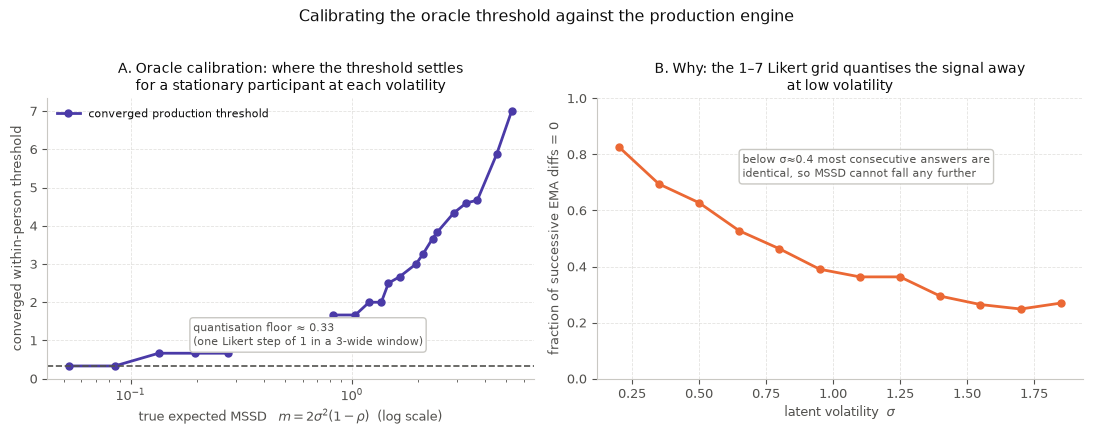

In [10]:
def fig_oracle_calibration(oracle_map, quant):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

    ax = axes[0]
    ax.plot(oracle_map["m"], oracle_map["threshold"], color="#4a3aa7",
            marker="o", ms=5, label="converged production threshold")
    floor = oracle_map["threshold"].iloc[0]
    ax.axhline(floor, color=INK_2, ls="--", lw=1.2)
    ax.annotate(f"quantisation floor ≈ {floor:.2f}\n(one Likert step of 1 in a 3-wide window)",
                xy=(0.30, 0.12), xycoords="axes fraction", fontsize=8, color=INK_2,
                bbox=dict(boxstyle="round", fc="white", ec=GRID))
    ax.set_xscale("log")
    ax.set_xlabel(r"true expected MSSD   $m = 2\sigma^2(1-\rho)$  (log scale)")
    ax.set_ylabel("converged within-person threshold")
    ax.set_title("A. Oracle calibration: where the threshold settles\nfor a stationary participant at each volatility")
    ax.legend(loc="upper left", fontsize=8)

    ax = axes[1]
    ax.plot(quant["sigma"], quant["zero_diff_frac"], color="#eb6834", marker="o", ms=5)
    ax.set_xlabel(r"latent volatility  $\sigma$")
    ax.set_ylabel("fraction of successive EMA diffs = 0")
    ax.set_ylim(0, 1)
    ax.set_title("B. Why: the 1–7 Likert grid quantises the signal away\nat low volatility")
    ax.annotate("below σ≈0.4 most consecutive answers are\nidentical, so MSSD cannot fall any further",
                xy=(0.30, 0.72), xycoords="axes fraction", fontsize=8, color=INK_2,
                bbox=dict(boxstyle="round", fc="white", ec=GRID))

    fig.suptitle("Calibrating the oracle threshold against the production engine", y=1.02,
                 fontsize=11.5)
    fig.tight_layout()
    return _save(fig, "oracle_calibration.png")


# ---- CELL: FIGURE 2 - mechanism, one exemplar participant ----


fig_oracle_calibration(oracle_map, quant)
plt.show()

## 4 · Running the simulationFull factorial: 4 scenarios × 2 threshold arms × 10 replications × 150 participants,paired on participants within a replication. The Bernoulli micro-randomisation($p = 0.50$, PI sign-off) is layered on top exactly as `backend/app/tasks.py::_evaluate_user`does it — the engine's `send_prompt` means *eligible*, not *delivered*.Detection is deliberately scored on the **threshold crossing itself**, not on`send_prompt`: the cooldown and daily cap would otherwise contaminate a measurement of howthe *threshold* behaves. Dosage is reported separately, and it is where the caps show up.

In [11]:
def run_arm(cohort, arm):
    """One cohort through one threshold arm. `expanding` calls the real engine."""
    m = calculate_mssd(cohort, window=MSSD_WINDOW)
    if arm == "expanding":
        return apply_decision_rules(
            m, threshold_quantile=THRESHOLD_QUANTILE,
            cooldown_minutes=COOLDOWN_MINUTES,
            max_prompts_per_day=MAX_PROMPTS_PER_DAY)
    if arm == "rolling":
        return apply_gate(add_rolling_within_person_threshold(
            m, THRESHOLD_QUANTILE, ROLLING_WINDOW))
    raise ValueError(arm)


def run_simulation(scenarios=SCENARIOS, arms=("expanding", "rolling"),
                   users=USERS, n_reps=N_REPS, seed=SEED):
    """Full factorial: scenario x arm x replication, paired on participants."""
    out = []
    for rep in range(n_reps):
        pop = draw_population(users=users, rep=rep, seed=seed)
        rand_rng = np.random.default_rng([seed, rep, 555])
        for scen in scenarios:
            cohort = add_latent_mssd(build_cohort(scen, pop, rep=rep, seed=seed))
            for arm in arms:
                d = run_arm(cohort, arm)
                # Bernoulli micro-randomisation layered on top, as in
                # backend/app/tasks.py::_evaluate_user (p = 0.50, PI sign-off).
                d["delivered"] = d["send_prompt"].to_numpy() & (
                    rand_rng.random(len(d)) < RANDOMIZATION_P)
                d["scenario"] = scen
                d["arm"] = arm
                d["rep"] = rep
                out.append(d)
    df = pd.concat(out, ignore_index=True)
    df["evaluable"] = (df["ema"].notna() & df["observed_mssd"].notna()
                       & df["user_threshold"].notna())
    df["crossed"] = df["evaluable"] & (df["observed_mssd"] > df["user_threshold"])
    df["tied"] = df["evaluable"] & (df["observed_mssd"] == df["user_threshold"])
    return df


def detection_metrics(g):
    """TPR / FPR / precision of the threshold crossing itself.

    Deliberately scored on threshold crossing rather than on `send_prompt`, so
    the cooldown and daily cap do not contaminate a measure of how the
    *threshold* behaves. Dosage is reported separately.
    """
    e = g[g["evaluable"]]
    if e.empty:
        return pd.Series(dict(tpr=np.nan, fpr=np.nan, precision=np.nan, n=0))
    t = e["truth_high_vol"].to_numpy()
    p = e["crossed"].to_numpy()
    tp, fp = int((t & p).sum()), int((~t & p).sum())
    fn, tn = int((t & ~p).sum()), int((~t & ~p).sum())
    return pd.Series(dict(
        tpr=tp / (tp + fn) if tp + fn else np.nan,
        fpr=fp / (fp + tn) if fp + tn else np.nan,
        precision=tp / (tp + fp) if tp + fp else np.nan,
        n=len(e)))

In [12]:
def ci95(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    return 1.96 * x.std(ddof=1) / np.sqrt(x.size) if x.size > 1 else np.nan


def by_day(df):
    """Per-participant-day dosage and threshold behaviour, averaged over the cohort."""
    per_pd = (df.groupby(["scenario", "arm", "rep", "user_id", "day"], observed=True)
                .agg(eligible=("send_prompt", "sum"),
                     delivered=("delivered", "sum"))
                .reset_index())
    dose = (per_pd.groupby(["scenario", "arm", "day"], observed=True)
                  .agg(eligible_mean=("eligible", "mean"),
                       eligible_ci=("eligible", ci95),
                       delivered_mean=("delivered", "mean"),
                       delivered_ci=("delivered", ci95),
                       n=("eligible", "size"))
                  .reset_index())

    ev = df[df["evaluable"]]
    thr = (ev.groupby(["scenario", "arm", "day"], observed=True)
             .agg(cross_rate=("crossed", "mean"),
                  tie_rate=("tied", "mean"),
                  threshold_med=("user_threshold", "median"),
                  oracle_med=("oracle_threshold", "median"),
                  tracking_ratio_med=("tracking_ratio", "median"),
                  observed_mssd_med=("observed_mssd", "median"),
                  n_eval=("crossed", "size"))
             .reset_index())
    return dose.merge(thr, on=["scenario", "arm", "day"], how="left")


def days_to_readapt(day_df, scenario, arm, shift_day=SHIFT_DAY, tol=0.25, smooth=3):
    """Days after the shift until the threshold catches up with the new regime.

    Measured on the tracking ratio (threshold / oracle threshold), not on the
    crossing rate: the ratio has a correct null (it sits at 1.0 for the whole
    stationary control, so the metric returns 0 days when nothing shifted),
    whereas a daily crossing rate is noisy enough to manufacture a lag from
    sampling error alone. Returns the first post-shift day whose smoothed ratio
    is within `tol` of 1.0 *and stays there*; NaN if it never settles.
    """
    s = (day_df[(day_df["scenario"] == scenario) & (day_df["arm"] == arm)]
         .sort_values("day"))
    ratio = (s.set_index("day")["tracking_ratio_med"]
              .rolling(smooth, center=True, min_periods=1).median())
    post = ratio.loc[ratio.index >= shift_day]
    inside = (post - 1.0).abs() <= tol
    settled = inside[::-1].cummin()[::-1]          # True only if it holds to the end
    hits = settled[settled].index
    final = float(ratio.iloc[-smooth:].mean())
    return (float(hits[0] - shift_day), final) if len(hits) else (np.nan, final)


def build_summary(df, day_df):
    """One row per scenario x arm: dosage, detection, tracking, ties, readaptation."""
    rows = []
    for (scen, arm), g in df.groupby(["scenario", "arm"], observed=True):
        pre, post = g[g["day"] < SHIFT_DAY], g[g["day"] >= SHIFT_DAY]
        det = detection_metrics(g)
        det_pre, det_post = detection_metrics(pre), detection_metrics(post)

        def ppw(x):
            per = (x.groupby(["rep", "user_id"], observed=True)["send_prompt"].sum()
                   / (x["day"].nunique() / 7.0))
            return float(per.mean())

        readapt, final_ratio = days_to_readapt(day_df, scen, arm)
        ev_post = post[post["evaluable"]]
        rows.append(dict(
            scenario=scen, arm=arm,
            prompts_per_week_pre=ppw(pre), prompts_per_week_post=ppw(post),
            delivered_per_day_post=float(
                post.groupby(["rep", "user_id", "day"], observed=True)["delivered"]
                    .sum().mean()),
            tpr=det["tpr"], fpr=det["fpr"], precision=det["precision"],
            tpr_pre=det_pre["tpr"], tpr_post=det_post["tpr"],
            fpr_pre=det_pre["fpr"], fpr_post=det_post["fpr"],
            tracking_ratio_pre=float(pre.loc[pre["evaluable"], "tracking_ratio"].median()),
            tracking_ratio_post=float(ev_post["tracking_ratio"].median()),
            tie_rate=float(g.loc[g["evaluable"], "tied"].mean()),
            days_to_readapt=readapt, tracking_ratio_final=final_ratio,
            n_evaluable=int(det["n"])))
    return pd.DataFrame(rows).sort_values(["scenario", "arm"]).reset_index(drop=True)

In [13]:
import time
_t = time.time()

decisions = add_truth(run_simulation(), oracle_map)
day_df = by_day(decisions)
summary = build_summary(decisions, day_df)

print(f"{len(decisions):,} decision rows in {time.time() - _t:.0f}s")
print("truth-positive rate by scenario (20% by construction):",
      decisions.groupby("scenario")["truth_high_vol"].mean().round(3).to_dict())

day_df.to_csv(os.path.join(OUT_DIR, "robustness_by_day.csv"), index=False)
summary.to_csv(os.path.join(OUT_DIR, "robustness_summary.csv"), index=False)
oracle_map.to_csv(os.path.join(OUT_DIR, "robustness_oracle_map.csv"), index=False)

pd.set_option("display.width", 250)
summary.round(3)

2,100,000 decision rows in 39s
truth-positive rate by scenario (20% by construction): {'drift': 0.2, 'shift_down': 0.2, 'shift_up': 0.2, 'stationary': 0.2}


,scenario,arm,prompts_per_week_pre,prompts_per_week_post,delivered_per_day_post,tpr,fpr,precision,tpr_pre,tpr_post,fpr_pre,fpr_post,tracking_ratio_pre,tracking_ratio_post,tie_rate,days_to_readapt,tracking_ratio_final,n_evaluable
0,drift,expanding,4.821,4.417,0.315,0.464,0.110,0.515,0.486,0.451,0.128,0.099,1.0,1.000,0.100,0.0,1.000,192274
1,drift,rolling,4.914,4.847,0.345,0.476,0.121,0.497,0.490,0.467,0.132,0.115,1.0,1.000,0.102,0.0,1.000,192274
2,shift_down,expanding,4.592,1.024,0.072,0.256,0.056,0.537,0.518,0.103,0.109,0.022,1.0,1.711,0.092,NaN,1.500,192274
3,shift_down,rolling,4.690,3.253,0.233,0.366,0.096,0.491,0.521,0.275,0.113,0.085,1.0,1.000,0.145,6.0,1.000,192274
4,shift_up,expanding,4.592,9.205,0.664,0.697,0.192,0.478,0.510,0.813,0.107,0.244,1.0,0.620,0.097,NaN,0.741,192274
5,shift_up,rolling,4.690,6.544,0.470,0.606,0.134,0.532,0.514,0.664,0.111,0.149,1.0,0.865,0.078,5.0,0.968,192274
6,stationary,expanding,4.592,4.076,0.289,0.511,0.082,0.611,0.512,0.510,0.108,0.066,1.0,1.000,0.116,0.0,1.000,192274
7,stationary,rolling,4.690,4.582,0.328,0.516,0.098,0.571,0.515,0.516,0.112,0.089,1.0,1.000,0.113,0.0,1.000,192274


### Sanity checks on the control armUnder stationarity the threshold is the 80th percentile of the participant's own MSSD, sothe crossing rate should approach $1 - 0.80 = 0.20$ *minus* exact ties (the gate is`observed_mssd <= user_threshold`, so ties block). On a discrete 1–7 Likert with a 3-widewindow, ties are common — worth quantifying, because the committed `high_volatility`golden scenario is 100% ties and fires **zero** prompts despite maximal instability.

In [14]:
ev = decisions[decisions["evaluable"] & (decisions["arm"] == "expanding")]
ctl = ev[ev["scenario"] == "stationary"]
print(f"stationary control, expanding (production) threshold:")
_c, _t = ctl["crossed"].mean(), ctl["tied"].mean()
print(f"  P(mssd >  threshold)   {_c:.3f}   <- fires")
print(f"  P(mssd == threshold)   {_t:.3f}   <- blocked, the gate is <=")
print(f"  P(mssd >= threshold)   {_c + _t:.3f}")
print(f"  a discrete 80th percentile must bracket {1 - THRESHOLD_QUANTILE:.2f}: "
      f"{_c:.3f} <= {1 - THRESHOLD_QUANTILE:.2f} <= {_c + _t:.3f}  "
      f"-> {'OK' if _c <= 1 - THRESHOLD_QUANTILE <= _c + _t else 'FAIL'}")
print()
print("decision-reason mix, production arm, before vs after the shift:")
mix = (ev.assign(period=np.where(ev["day"] < SHIFT_DAY, "pre", "post"))
         .groupby(["scenario", "period"])["decision_reason"]
         .value_counts(normalize=True).unstack(fill_value=0).round(3))
mix.loc[:, mix.sum().sort_values(ascending=False).index]

stationary control, expanding (production) threshold:
  P(mssd >  threshold)   0.168   <- fires
  P(mssd == threshold)   0.116   <- blocked, the gate is <=
  P(mssd >= threshold)   0.284
  a discrete 80th percentile must bracket 0.20: 0.168 <= 0.20 <= 0.284  -> OK

decision-reason mix, production arm, before vs after the shift:


decision_reason    below within-person threshold  prompt sent  daily cap reached
scenario   period                                                               
drift      post                            0.830        0.167              0.003
           pre                             0.801        0.197              0.003
shift_down post                            0.961        0.039              0.000
           pre                             0.811        0.187              0.002
shift_up   post                            0.641        0.349              0.010
           pre                             0.811        0.187              0.002
stationary post                            0.844        0.154              0.001
           pre                             0.811        0.187              0.002

## 5 · Figures

wrote /Users/tienle/Documents/Coding/REACT-SMASH/REACT/analytics/sensitivity_analysis/figures/robustness/mechanism_exemplar.png


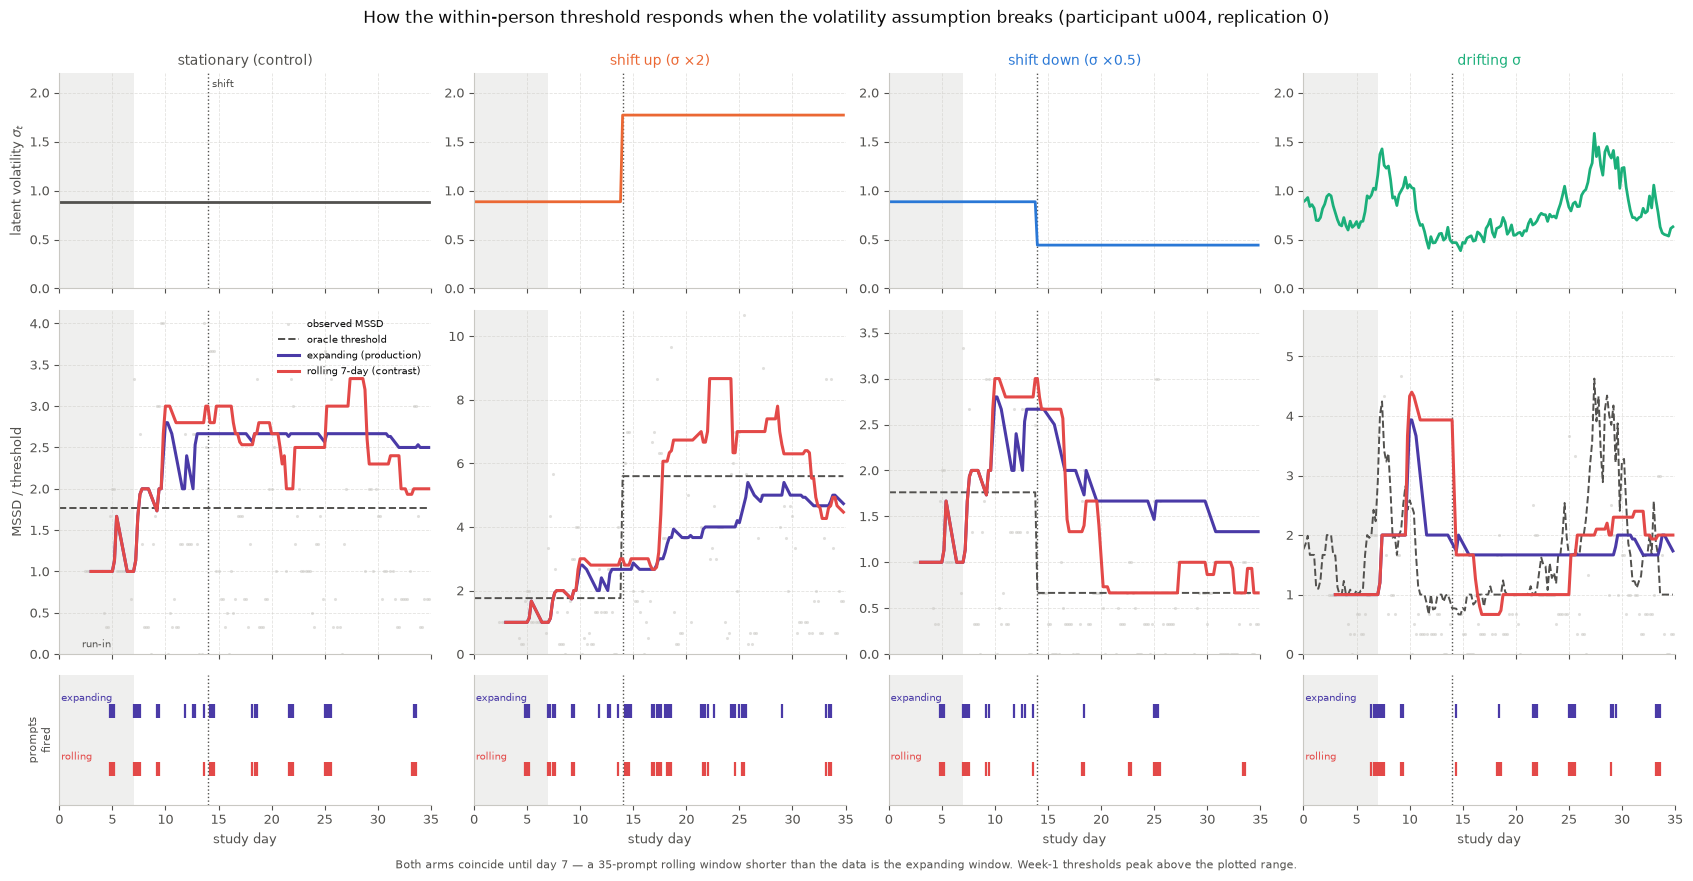

In [15]:
def fig_mechanism(df, exemplar, rep=0):
    fig, axes = plt.subplots(3, 4, figsize=(17, 8.5), sharex=True,
                             gridspec_kw={"height_ratios": [1, 1.6, 0.6]})
    for j, scen in enumerate(SCENARIOS):
        sub = df[(df["scenario"] == scen) & (df["rep"] == rep)
                 & (df["user_id"] == exemplar)]
        exp = sub[sub["arm"] == "expanding"].sort_values("prompt_idx")
        rol = sub[sub["arm"] == "rolling"].sort_values("prompt_idx")
        x = exp["prompt_idx"].to_numpy() / EMA_PER_DAY

        ax = axes[0, j]
        ax.plot(x, exp["sigma_t"], color=SCEN_COLOR[scen], lw=2)
        ax.set_title(SCEN_LABEL[scen], color=SCEN_COLOR[scen])
        ax.set_ylim(0, 2.2)
        ax.set_xlim(0, DAYS)
        if j == 0:
            ax.set_ylabel(r"latent volatility $\sigma_t$")
        _runin_band(ax)
        _shift_marker(ax, label=(j == 0))

        ax = axes[1, j]
        ax.scatter(x, exp["observed_mssd"], s=5, color=GRID, alpha=0.55,
                   zorder=1, label="observed MSSD", linewidths=0)
        ax.plot(x, exp["oracle_threshold"], color=INK_2, ls="--", lw=1.4, zorder=2,
                label="oracle threshold")
        ax.plot(x, exp["user_threshold"], color=ARM_COLOR["expanding"], lw=2.2, zorder=3,
                label=ARM_LABEL["expanding"])
        ax.plot(x, rol["user_threshold"], color=ARM_COLOR["rolling"], lw=2.2, zorder=3,
                label=ARM_LABEL["rolling"])
        # Scale to the post-run-in range. Both arms peak far above this during
        # week 1 and clip off the top of the panel: that burn-in is the point of
        # the shaded band, not something to design the y-axis around.
        settled = pd.concat([exp[exp["day"] >= RUN_IN_DAYS],
                             rol[rol["day"] >= RUN_IN_DAYS]])
        top = np.nanmax(np.r_[settled["user_threshold"].to_numpy(),
                              settled["oracle_threshold"].to_numpy()])
        ax.set_ylim(0, top * 1.25)
        ax.set_xlim(0, DAYS)
        if j == 0:
            ax.set_ylabel("MSSD / threshold")
            ax.legend(loc="upper right", fontsize=7.5)
        _runin_band(ax, label=(j == 0))
        _shift_marker(ax, label=False)

        ax = axes[2, j]
        for i, arm in enumerate(("expanding", "rolling")):
            s = exp if arm == "expanding" else rol
            hit = s[s["send_prompt"]]
            ax.scatter(hit["prompt_idx"] / EMA_PER_DAY, np.full(len(hit), 1 - i),
                       marker="|", s=90, linewidths=1.6, color=ARM_COLOR[arm])
            ax.annotate(arm, xy=(0.005, 1 - i), xycoords=("axes fraction", "data"),
                        xytext=(0, 7), textcoords="offset points",
                        fontsize=7.5, color=ARM_COLOR[arm])
        ax.set_ylim(-0.6, 1.6)
        ax.set_xlim(0, DAYS)
        ax.set_yticks([])
        ax.set_xlabel("study day")
        ax.grid(False)
        if j == 0:
            ax.set_ylabel("prompts\nfired", fontsize=8)
        _runin_band(ax)
        _shift_marker(ax, label=False)

    fig.suptitle(f"How the within-person threshold responds when the volatility assumption breaks "
                 f"(participant {exemplar}, replication {rep})", y=1.0, fontsize=12)
    fig.text(0.5, -0.01,
             "Both arms coincide until day 7 — a 35-prompt rolling window shorter than the data "
             "is the expanding window. Week-1 thresholds peak above the plotted range.",
             ha="center", fontsize=8, color=INK_2)
    fig.tight_layout()
    return _save(fig, "mechanism_exemplar.png")


# ---- CELL: FIGURE 3 - dosage over time ----


EXEMPLAR = "u%03d" % int(
    draw_population(users=USERS, rep=0)
    .pipe(lambda p: p.iloc[(p.sigma0 - p.sigma0.median()).abs().argsort().iloc[0]]).user_idx)
fig_mechanism(decisions, EXEMPLAR)
plt.show()

wrote /Users/tienle/Documents/Coding/REACT-SMASH/REACT/analytics/sensitivity_analysis/figures/robustness/dosage_over_time.png


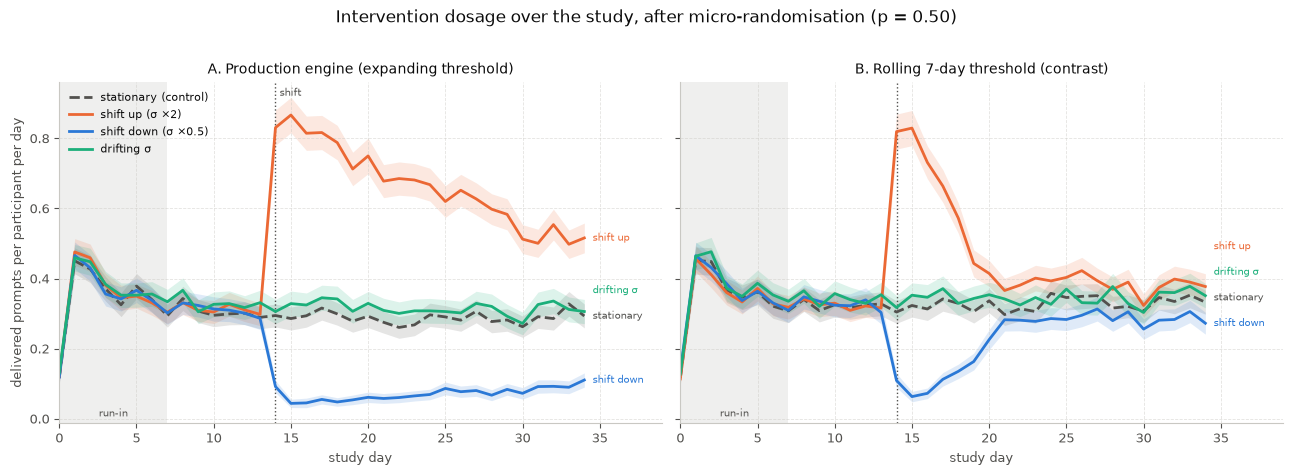

In [16]:
def fig_dosage(day_df):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharex=True, sharey=True)
    for ax, (arm, title) in zip(axes, [("expanding", "A. Production engine (expanding threshold)"),
                                       ("rolling", "B. Rolling 7-day threshold (contrast)")]):
        ends = []
        for scen in SCENARIOS:
            s = day_df[(day_df["scenario"] == scen) & (day_df["arm"] == arm)].sort_values("day")
            ax.plot(s["day"], s["delivered_mean"], color=SCEN_COLOR[scen],
                    ls=SCEN_STYLE[scen], label=SCEN_LABEL[scen])
            ax.fill_between(s["day"], s["delivered_mean"] - s["delivered_ci"],
                            s["delivered_mean"] + s["delivered_ci"],
                            color=SCEN_COLOR[scen], alpha=0.15, lw=0)
            ends.append((float(s["delivered_mean"].iloc[-1]),
                         SCEN_LABEL[scen].split(" (")[0], SCEN_COLOR[scen]))
        ax.set_xlabel("study day")
        ax.set_title(title)
        ax.set_xlim(0, DAYS + 4)
        _runin_band(ax, label=True)
        _end_labels(ax, ends, DAYS - 1)
        _shift_marker(ax, label=(arm == "expanding"))
    axes[0].set_ylabel("delivered prompts per participant per day")
    axes[0].legend(loc="upper left", fontsize=8)
    fig.suptitle("Intervention dosage over the study, after micro-randomisation (p = 0.50)",
                 y=1.02, fontsize=12)
    fig.tight_layout()
    return _save(fig, "dosage_over_time.png")


# ---- CELL: FIGURE 4 - threshold tracking ----


fig_dosage(day_df)
plt.show()

wrote /Users/tienle/Documents/Coding/REACT-SMASH/REACT/analytics/sensitivity_analysis/figures/robustness/threshold_tracking.png


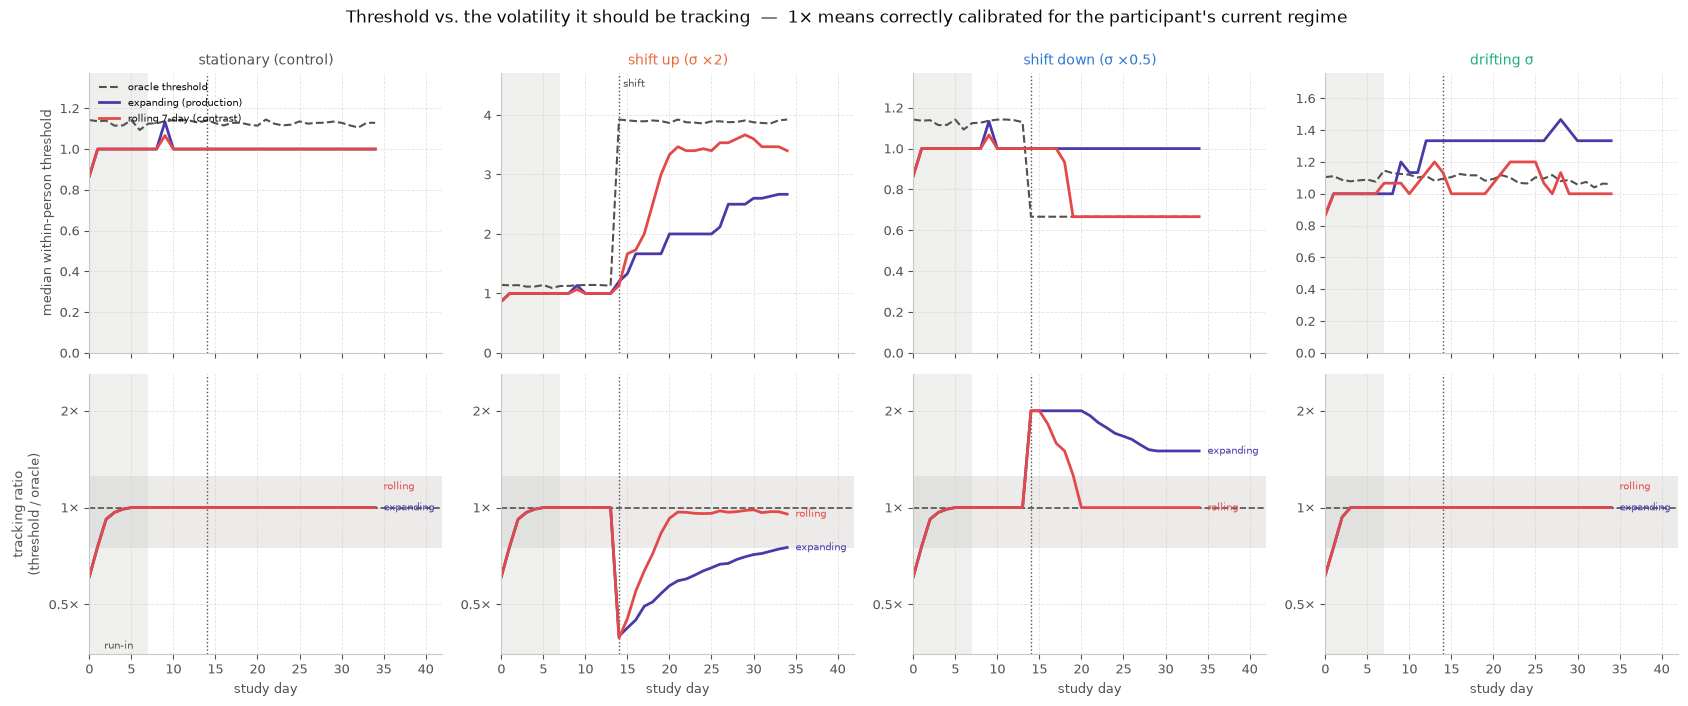

In [17]:
def fig_tracking(day_df):
    fig, axes = plt.subplots(2, 4, figsize=(17, 7), sharex=True)
    for j, scen in enumerate(SCENARIOS):
        ax = axes[0, j]
        base = day_df[(day_df["scenario"] == scen) & (day_df["arm"] == "expanding")].sort_values("day")
        ax.plot(base["day"], base["oracle_med"], color=INK_2, ls="--", lw=1.5,
                label="oracle threshold")
        for arm in ("expanding", "rolling"):
            s = day_df[(day_df["scenario"] == scen) & (day_df["arm"] == arm)].sort_values("day")
            ax.plot(s["day"], s["threshold_med"], color=ARM_COLOR[arm], label=ARM_LABEL[arm])
        ax.set_title(SCEN_LABEL[scen], color=SCEN_COLOR[scen])
        top = np.nanmax(np.r_[
            day_df[day_df["scenario"] == scen]["threshold_med"].to_numpy(),
            base["oracle_med"].to_numpy()])
        ax.set_ylim(0, top * 1.2)
        _runin_band(ax)
        if j == 0:
            ax.set_ylabel("median within-person threshold")
            ax.legend(loc="upper left", fontsize=7.5)
        _shift_marker(ax, label=(j == 1))

        ax = axes[1, j]
        ends = []
        ax.axhline(1.0, color=INK_2, ls="--", lw=1.2)
        ax.axhspan(0.75, 1.25, color=GRID, alpha=0.35, lw=0)
        for arm in ("expanding", "rolling"):
            s = day_df[(day_df["scenario"] == scen) & (day_df["arm"] == arm)].sort_values("day")
            ax.plot(s["day"], s["tracking_ratio_med"], color=ARM_COLOR[arm],
                    label=ARM_LABEL[arm])
            ends.append((float(s["tracking_ratio_med"].iloc[-1]), arm, ARM_COLOR[arm]))
        ax.set_yscale("log")
        ax.minorticks_off()
        ax.set_yticks([0.5, 1.0, 2.0])
        ax.set_yticklabels(["0.5×", "1×", "2×"])
        ax.set_ylim(0.35, 2.6)
        ax.set_xlim(0, DAYS + 7)
        _end_labels(ax, ends, DAYS - 1, log=True)
        ax.set_xlabel("study day")
        _runin_band(ax, label=(j == 0))
        if j == 0:
            ax.set_ylabel("tracking ratio\n(threshold / oracle)")
        _shift_marker(ax, label=False)

    fig.suptitle("Threshold vs. the volatility it should be tracking  —  1× means correctly calibrated "
                 "for the participant's current regime", y=1.0, fontsize=12)
    fig.tight_layout()
    return _save(fig, "threshold_tracking.png")


# ---- CELL: FIGURE 5 - detection performance ----


fig_tracking(day_df)
plt.show()

wrote /Users/tienle/Documents/Coding/REACT-SMASH/REACT/analytics/sensitivity_analysis/figures/robustness/detection_performance.png


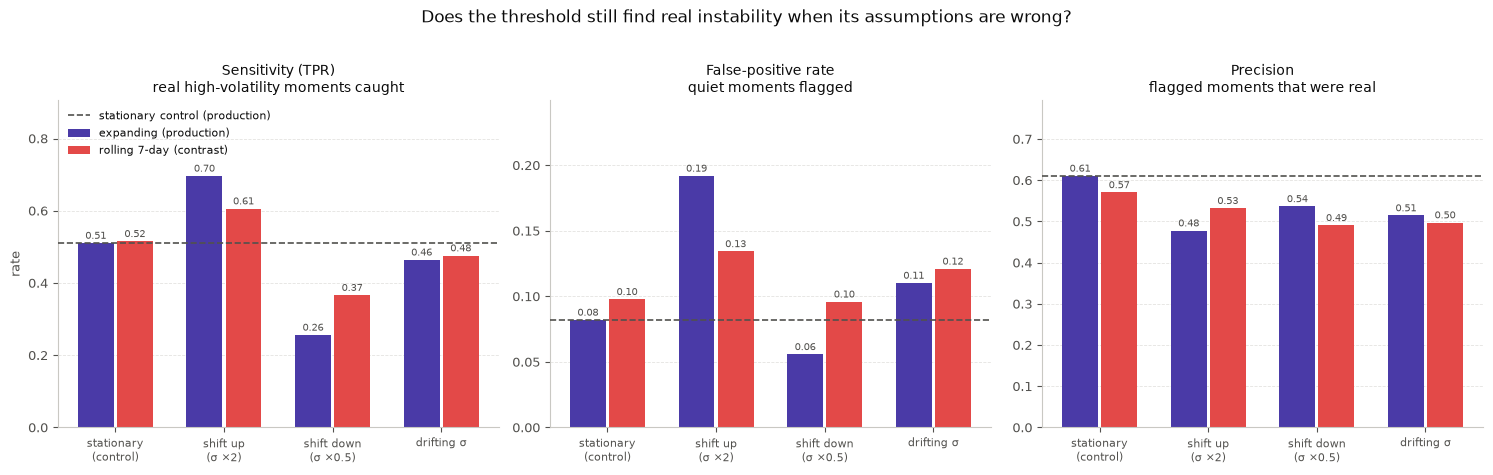

In [18]:
def fig_detection(summ):
    metrics = [("tpr", "Sensitivity (TPR)\nreal high-volatility moments caught"),
               ("fpr", "False-positive rate\nquiet moments flagged"),
               ("precision", "Precision\nflagged moments that were real")]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
    xs = np.arange(len(SCENARIOS))
    w = 0.36
    for ax, (col, title) in zip(axes, metrics):
        panel_max = 0.0
        for i, arm in enumerate(("expanding", "rolling")):
            vals = [float(summ[(summ.scenario == s) & (summ.arm == arm)][col].iloc[0])
                    for s in SCENARIOS]
            panel_max = max(panel_max, max(vals))
            ax.bar(xs + (i - 0.5) * w, vals, width=w - 0.03, color=ARM_COLOR[arm],
                   label=ARM_LABEL[arm], zorder=2)
            for x, v in zip(xs + (i - 0.5) * w, vals):
                ax.annotate(f"{v:.2f}", xy=(x, v), xytext=(0, 3),
                            textcoords="offset points", ha="center",
                            fontsize=7.5, color=INK_2)
        ref = float(summ[(summ.scenario == "stationary") & (summ.arm == "expanding")][col].iloc[0])
        ax.axhline(ref, color=INK_2, ls="--", lw=1.2, zorder=3,
                   label="stationary control (production)")
        ax.set_xticks(xs)
        ax.set_xticklabels([SCEN_LABEL[s].replace(" (", "\n(") for s in SCENARIOS], fontsize=8)
        ax.set_title(title)
        ax.set_ylim(0, panel_max * 1.3)
        ax.grid(axis="x", visible=False)
    axes[0].set_ylabel("rate")
    axes[0].legend(loc="upper left", fontsize=8)
    fig.suptitle("Does the threshold still find real instability when its assumptions are wrong?",
                 y=1.02, fontsize=12)
    fig.tight_layout()
    return _save(fig, "detection_performance.png")


# ---- CELL: FIGURE 6 - readaptation ----


fig_detection(summary)
plt.show()

wrote /Users/tienle/Documents/Coding/REACT-SMASH/REACT/analytics/sensitivity_analysis/figures/robustness/readaptation_expanding_vs_rolling.png


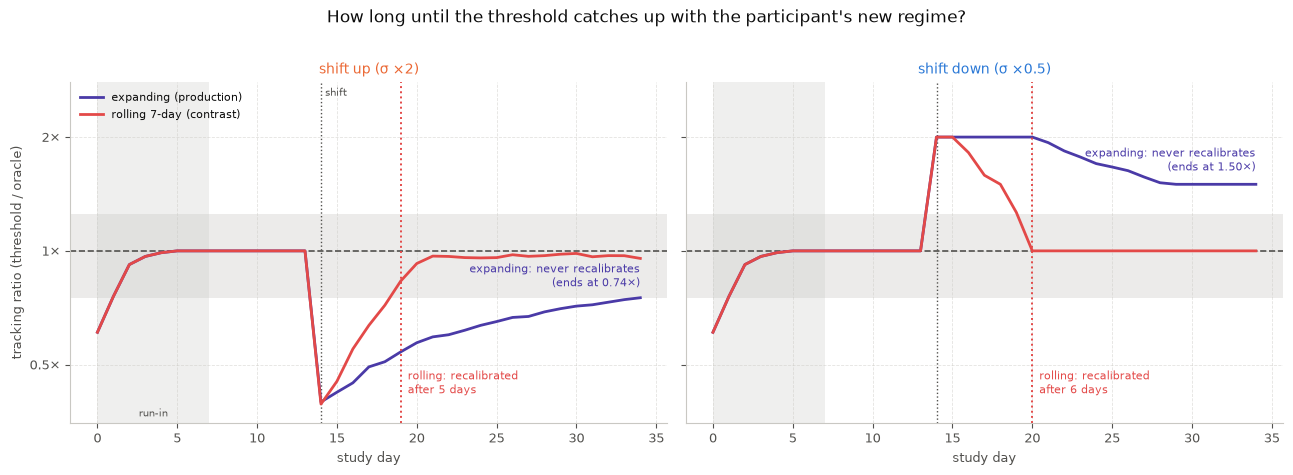

In [19]:
def fig_readaptation(day_df, summ):
    shifts = ["shift_up", "shift_down"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
    for ax, scen in zip(axes, shifts):
        ax.axhline(1.0, color=INK_2, ls="--", lw=1.2)
        ax.axhspan(0.75, 1.25, color=GRID, alpha=0.35, lw=0)
        for arm in ("expanding", "rolling"):
            s = day_df[(day_df["scenario"] == scen) & (day_df["arm"] == arm)].sort_values("day")
            ax.plot(s["day"], s["tracking_ratio_med"], color=ARM_COLOR[arm], label=ARM_LABEL[arm])
            row = summ[(summ.scenario == scen) & (summ.arm == arm)].iloc[0]
            d = row["days_to_readapt"]
            if np.isfinite(d):
                ax.axvline(SHIFT_DAY + d, color=ARM_COLOR[arm], ls=":", lw=1.4)
                ax.annotate(f"{arm}: recalibrated\nafter {int(d)} days",
                            xy=(SHIFT_DAY + d, 0.42), xytext=(5, 0),
                            textcoords="offset points", fontsize=8, color=ARM_COLOR[arm])
            else:
                ax.annotate(f"{arm}: never recalibrates\n(ends at {row['tracking_ratio_final']:.2f}×)",
                            xy=(DAYS - 0.5, row["tracking_ratio_final"]), xytext=(-6, 10),
                            textcoords="offset points", ha="right", fontsize=8,
                            color=ARM_COLOR[arm])
        ax.set_yscale("log")
        ax.minorticks_off()
        ax.set_yticks([0.5, 1.0, 2.0])
        ax.set_yticklabels(["0.5×", "1×", "2×"])
        ax.set_ylim(0.35, 2.8)
        ax.set_xlabel("study day")
        ax.set_title(SCEN_LABEL[scen], color=SCEN_COLOR[scen])
        _runin_band(ax, label=(scen == "shift_up"))
        _shift_marker(ax, label=(scen == "shift_up"))
    axes[0].set_ylabel("tracking ratio (threshold / oracle)")
    axes[0].legend(loc="upper left", fontsize=8)
    fig.suptitle("How long until the threshold catches up with the participant's new regime?",
                 y=1.02, fontsize=12)
    fig.tight_layout()
    return _save(fig, "readaptation_expanding_vs_rolling.png")


fig_readaptation(day_df, summary)
plt.show()

## 6 · Result summaryParameters: 150 participants × 10 replications × 4 scenarios × 2 threshold arms,35 days, 5 EMA/day, 80% response rate, `SEED = 42`. Detection is scored on thresholdcrossing; dosage is post-randomisation. Full table in `outputs/robustness_summary.csv`.### The control behaves as designedWith stationary volatility the production threshold sits exactly on the oracle(tracking ratio 1.00 for the whole study), catches 51% of real high-volatility momentsat an 8% false-positive rate, and delivers ~4.6 eligible prompts/participant/week. Tiesblock ~12% of decisions — a consequence of a coarse 1–7 Likert under a `<=` gate, and thereason the committed `high_volatility` golden scenario fires zero prompts.### Under misspecification it fails in two opposite directions, and never recovers| | stationary | shift up (σ ×2) | shift down (σ ×0.5) | drifting σ ||---|---|---|---|---|| **sensitivity (TPR)** | 0.51 | 0.70 | **0.26** | 0.46 || **false-positive rate** | 0.08 | **0.19** | 0.06 | 0.11 || **precision** | 0.61 | **0.48** | 0.54 | 0.52 || **prompts/week, pre-shift** | 4.6 | 4.6 | 4.6 | 4.8 || **prompts/week, post-shift** | 4.1 | **9.2** | **1.0** | 4.4 || **tracking ratio, post-shift** | 1.00 | **0.62** | **1.71** | 1.00 || **tracking ratio, study end** | 1.00 | 0.74 | 1.50 | 1.00 || **days to recalibrate** | 0 | **never** | **never** | 0 |- **Volatility rises (`shift_up`).** The threshold is anchored to the calm pre-shift weeks,  so it sits at 0.62× where it should be. Eligible dosage doubles to 9.2 prompts/week and  the false-positive rate rises from 0.08 to 0.19 — precision *falls* (0.61 → 0.48) even  though sensitivity rises to 0.70. More prompts, a smaller share of them warranted.- **Volatility falls (`shift_down`).** The far more dangerous case, and invisible from the  dashboard. The threshold is stranded 1.7× too high, dosage collapses from 4.6 to 1.0  prompts/week, and sensitivity halves to 0.26. The participant still has high-volatility  moments relative to their new normal; the engine has simply stopped responding to them.  Nothing errors, no alert fires — the intervention just goes quiet.- **Drift.** Milder, but the loss is real and permanent: sensitivity 0.46 vs 0.51, and  the aggregate tracking ratio of 1.00 hides per-participant lag that averages out across  a cohort drifting in both directions.- **Neither shift is ever recovered from.** 21 days after the break the threshold is still  at 0.74× / 1.50×. The expanding quantile's memory is the whole study, so a mid-study  break is permanent within a 35-day protocol.### The rolling contrastA trailing 7-day window recalibrates in **5–6 days** in both directions, returning thetracking ratio to 1.00, dosage to the control band, and recovering most of the lostsensitivity under `shift_down` (0.26 → 0.37). It costs a little on the stationary control —precision 0.61 → 0.57 — because a 35-observation reference sample is noisier than a175-observation one. That is the trade: responsiveness against calibration precision.

## 7 · Interpretation**The threshold is adaptive in name only.** It personalises *across* participants but not*within* a participant over time. An expanding quantile converges — and a convergedestimator is, by construction, one that stops responding. The design assumes volatility isa stable personal trait; the moment it is a state, the threshold is measuring a person whono longer exists.**Silence is the failure mode that matters.** Over-firing after `shift_up` is visible andbounded — the daily cap and 60-minute cooldown catch it, and a dosage spike shows up inmonitoring. Under-firing after `shift_down` is bounded by nothing and shows up as *fewer*prompts, which is indistinguishable in the dashboard from a well-behaved calm participant.Over a 12–14 week football season, a participant who habituates in October could beeffectively un-enrolled for the rest of the study without anyone noticing.**This interacts badly with the Week-1 run-in.** `data-dictionary.md` reserves Week 1 tocalibrate the threshold. That is the right instinct, and the run-in band in the figuresshows why it is needed — the first week's thresholds are quantiles of a 3–5 observationsample and sit far above where they settle. But calibrating *once* is exactly the designthat a regime shift defeats. The run-in fixes the cold-start problem and creates thestaleness problem.**A second, separate limitation surfaced.** At low volatility the 1–7 Likert grid quantisesthe signal away: below σ ≈ 0.4, 60–80% of consecutive answers are identical, so observedMSSD cannot fall below ~0.33 no matter how calm the participant is. Calm participants aretherefore not distinguishable from each other, and MSSD-based triggering has a floor thatno threshold rule can undo. This is a measurement-scale property, independent of thestationarity question.### What this does and does not supportThis is simulation evidence about a **design parameter that requires PI sign-off**, so therecommendation here is deliberately narrow:1. **Worth raising with Prof. Chang:** whether the within-person reference should be a   trailing window rather than the full history. The 7-day window used here is illustrative,   not proposed — its length is itself a calibration question, and it trades precision for   responsiveness.2. **Worth adding regardless of that decision:** a monitoring check for participants whose   prompt rate collapses relative to their own earlier weeks. That is a dashboard addition,   not a threshold change, and it makes the silent failure visible.3. **Not supported by this notebook:** any specific replacement threshold. Only two rules   were compared, on synthetic data, under one shift magnitude (σ ×2 / ×0.5) at one   breakpoint (day 14).### Caveats- Synthetic AR(1) EMA, not participant data. The shift is imposed as a clean step at a  known time; real regime changes are gradual and confounded with response-rate changes.- Every participant shifts on the same day. A cohort shifting at staggered times would  blur the aggregate curves while leaving the per-participant mechanism unchanged.- ρ is held fixed so the manipulation is purely volatility. Misspecified *autocorrelation*  is a separate case and is not tested here.- Decision points here are EMA completions (~4/day at 80% response), matching  `evaluate_jitai_triggers`, which acts only on a newly completed EMA. Absolute dosage is  therefore not comparable to the 2–3/day projection in `data-dictionary.md`; the  cross-scenario *ratios* are the finding.### Footnote for whoever analyses the real data`analytics/scripts.py::compute_within_person_threshold` (line 767) takes the expandingquantile of the **raw squared diffs**, while the engine takes it of the **rolling-window`observed_mssd`**. These are not the same quantity — offline analysis via `scripts.py` willnot reproduce the threshold the engine actually used. `JITAILog.observed_mssd` remains theaudit source.

In [20]:
findings = os.path.join(FIG_DIR, "findings.md")
tbl = summary[["scenario", "arm", "tpr", "fpr", "precision", "prompts_per_week_pre",
               "prompts_per_week_post", "tracking_ratio_post", "tracking_ratio_final",
               "days_to_readapt", "tie_rate"]].round(3)


def _md_table(d):
    # markdown table, without pulling in tabulate as a dependency
    cols = [str(c) for c in d.columns]
    out = ["| " + " | ".join(cols) + " |",
           "|" + "|".join(["---"] * len(cols)) + "|"]
    for row in d.itertuples(index=False):
        cells_ = ["" if pd.isna(v) else (f"{v:g}" if isinstance(v, (int, float, np.floating))
                                         else str(v)) for v in row]
        out.append("| " + " | ".join(cells_) + " |")
    return chr(10).join(out)


lines = [
    "# Robustness to model misspecification",
    "",
    "Author: Tyler Le",
    "",
    "Date: 09/04/2026",
    "",
    "Generated by `robustness_misspecification.ipynb`. The interpretation lives in that",
    "notebook; this file is the machine-written record of the numbers.",
    "",
    (f"Parameters: {USERS} participants x {N_REPS} replications, {DAYS} days, "
     f"{EMA_PER_DAY} EMA/day, response rate {RESP_RATE}, shift at day {SHIFT_DAY}, "
     f"threshold quantile {THRESHOLD_QUANTILE}, SEED {SEED}."),
    "",
    "Detection (tpr / fpr / precision) is scored on threshold crossing, so the cooldown and",
    "daily cap do not contaminate a measure of the threshold itself. Dosage is",
    "post-randomisation (p = 0.50). `tracking_ratio` is threshold / oracle threshold, where",
    "1.0 means correctly calibrated for the participant's current regime.",
    "`days_to_readapt` is measured on the tracking ratio and is only meaningful for the two",
    "shift scenarios; stationary = 0 is the null check, and NaN means it never recalibrated",
    "within the study.",
    "",
    _md_table(tbl),
    "",
    "## Figures",
    "",
]
lines += [f"- `{f}`" for f in
          ["oracle_calibration.png", "mechanism_exemplar.png", "dosage_over_time.png",
           "threshold_tracking.png", "detection_performance.png",
           "readaptation_expanding_vs_rolling.png"]]

with open(findings, "w") as fh:
    fh.write(chr(10).join(lines) + chr(10))

print("wrote", findings)
print(tbl.to_string(index=False))

wrote /Users/tienle/Documents/Coding/REACT-SMASH/REACT/analytics/sensitivity_analysis/figures/robustness/findings.md
  scenario       arm   tpr   fpr  precision  prompts_per_week_pre  prompts_per_week_post  tracking_ratio_post  tracking_ratio_final  days_to_readapt  tie_rate
     drift expanding 0.464 0.110      0.515                 4.821                  4.417                1.000                 1.000              0.0     0.100
     drift   rolling 0.476 0.121      0.497                 4.914                  4.847                1.000                 1.000              0.0     0.102
shift_down expanding 0.256 0.056      0.537                 4.592                  1.024                1.711                 1.500              NaN     0.092
shift_down   rolling 0.366 0.096      0.491                 4.690                  3.253                1.000                 1.000              6.0     0.145
  shift_up expanding 0.697 0.192      0.478                 4.592                  9.205